In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from matplotlib.lines import Line2D
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


In [11]:
df_avg = pd.read_csv("carnitines_with_putative_explanation_only_CHO.tsv", sep = "\t")

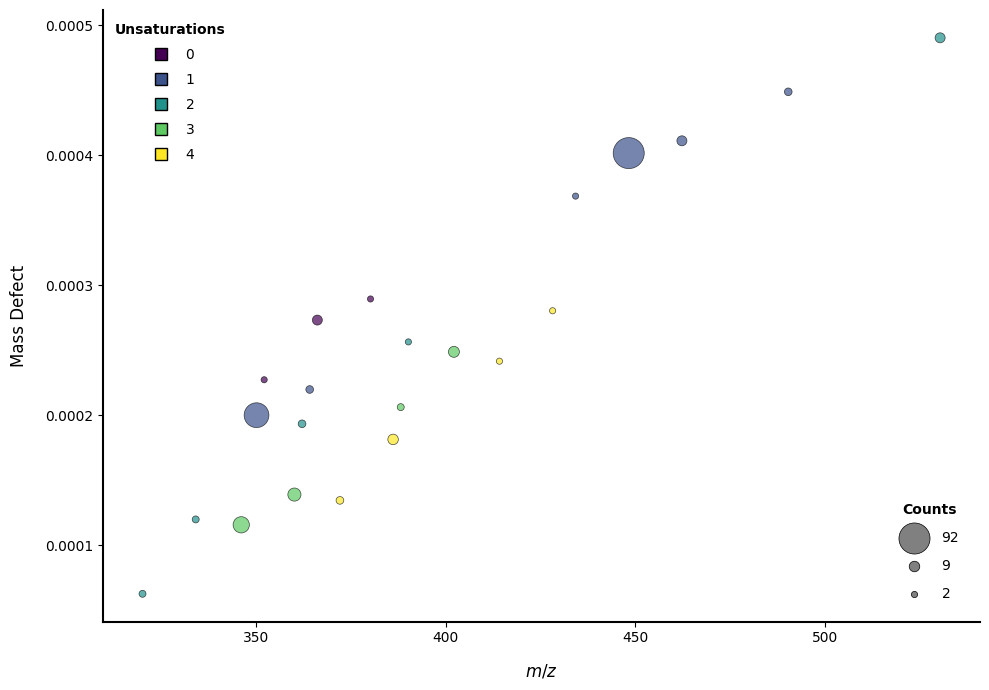

In [17]:
# Assume your DataFrame is named df_avg and already loaded in your workspace.

# --- START OF PLOT CODE ---

# 1) Control variable: set the number of oxygens to filter
NUM_OXYGENS = 4  # Change this value to 1, 2, 3, etc.

# 2) Extract the number of oxygens and unsaturations
# The pattern 'C\d+:(\d+);O(\d*)' captures the number of unsaturations (y) and oxygens (z).
def extract_oxygen_and_unsaturation(explanation: str):
    match = re.search(r'C\d+:(\d+);O(\d*)', str(explanation))
    if match:
        unsaturations = int(match.group(1))
        oxygen_str = match.group(2)
        oxygens = int(oxygen_str) if oxygen_str else 1
        return unsaturations, oxygens
    return None, None

df_temp = df_avg.copy()
df_temp['unsaturations'], df_temp['oxygens'] = zip(
    *df_temp['putative explanation'].apply(extract_oxygen_and_unsaturation)
)

# 3) Filter the DataFrame for the specific number of oxygens
df_filtered = df_temp[df_temp['oxygens'] == NUM_OXYGENS].dropna(subset=['unsaturations'])

if df_filtered.empty:
    print(f"No data found for the number of oxygens: {NUM_OXYGENS}.")
else:
    # 4) Scale 'counts' using linear normalization
    min_counts = df_filtered['counts'].min()
    max_counts = df_filtered['counts'].max()

    # Define minimum and maximum point sizes
    min_size = 20   # minimum point size
    max_size = 500  # maximum point size

    # Normalize counts to the new range
    df_filtered.loc[:, 'scaled_counts'] = (
        min_size
        + (df_filtered['counts'] - min_counts) * (max_size - min_size) / (max_counts - min_counts)
    )

    # 5) Create color palette per unsaturation
    unique_unsaturations = sorted(df_filtered['unsaturations'].unique())
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_unsaturations)))
    color_map = dict(zip(unique_unsaturations, colors))

    # 6) Figure setup
    fig, ax = plt.subplots(figsize=(10, 7))

    # 7) Scatter points with black edge
    for unsaturation, group in df_filtered.groupby('unsaturations'):
        ax.scatter(
            group['precmz'],
            group['mass_defect'],
            s=group['scaled_counts'],
            c=[color_map[unsaturation]],
            label=f'{int(unsaturation)}',  # format as integer
            alpha=0.7,
            edgecolors='k',  # black edge
            linewidth=0.5
        )

    # 8) Style and formatting
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(False)

    # Thicken axis lines
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)

    # Axis labels
    ax.set_xlabel('$m/z$', style='italic', fontsize=12, labelpad=12)
    ax.set_ylabel('Mass Defect', fontsize=12, labelpad=12)

    # 9) Unsaturations legend (top-left) — square markers with fixed size
    unsat_handles = [
        Line2D([0], [0],
               marker='s', linestyle='None',
               markerfacecolor=color_map[u],
               markeredgecolor='k',
               markersize=8,          # fixed legend marker size
               label=f'{int(u)}')
        for u in unique_unsaturations
    ]
    legend1 = ax.legend(
        handles=unsat_handles,
        loc='upper left',
        frameon=False,
        labelspacing=0.8
    )
    legend1.set_title("Unsaturations", prop={'weight': 'bold'})

    # 10) Size legend (Counts) in the lower-right corner
    sizes = df_filtered['counts'].drop_duplicates().sort_values(ascending=False)
    if len(sizes) > 3:
        sizes = sizes.iloc[[0, len(sizes)//2, -1]]
    elif len(sizes) < 3:
        sizes = sizes.iloc[0:len(sizes)]

    scaled_sizes = (
        min_size + (sizes - min_counts) * (max_size - min_size) / (max_counts - min_counts)
    )

    legend_markers = [
        plt.scatter([], [], s=s, color='gray', edgecolors='k', linewidth=0.5, label=str(int(size)))
        for s, size in zip(scaled_sizes, sizes)
    ]

    legend2 = ax.legend(
        handles=legend_markers,
        loc='lower right',
        frameon=False,
        title='Counts',
        labelspacing=1,
        borderpad=1,
        handletextpad=1,
    )
    legend2.set_title("Counts", prop={'weight': 'bold'})

    # Add the first legend back
    ax.add_artist(legend1)

    plt.tight_layout()

    # Output filename
    file_name = "Figure S2_mass_defect_plot_CHO_with_oxygen_4.pdf"

    # Export at high resolution
    plt.savefig(file_name, bbox_inches='tight')

    # Show the figure
    plt.show()
